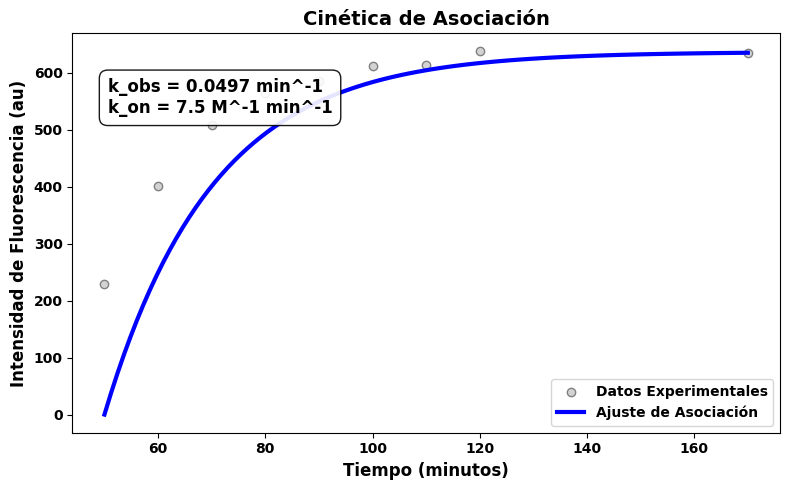

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Configurar todo el texto en negrita globalmente
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold', 'axes.titleweight': 'bold'})

# 2. Cargar los datos
df = pd.read_excel('DatosEnCrudo.xlsx', header=None)
tiempo_real = df[7].dropna().values
fluorescencia = df[8].dropna().values

# 3. Parámetros de Asociación
k_obs = 0.04968
k_on = 7.5
Y_max = 637.0
t_inyeccion = 50
t_lavado = 170

# 4. Filtrar datos
mascara = (tiempo_real >= t_inyeccion) & (tiempo_real <= t_lavado)
t_datos = tiempo_real[mascara]
f_datos = fluorescencia[mascara]

# 5. Curva matemática teórica
t_teorico = np.linspace(t_inyeccion, t_lavado, 100)
t_ajustado = t_teorico - t_inyeccion
curva_asoc = Y_max * (1 - np.exp(-k_obs * t_ajustado))

# 6. Crear la gráfica
fig, ax = plt.subplots(figsize=(8, 5))

# Puntos y línea
ax.scatter(t_datos, f_datos, color='lightgray', edgecolors='gray', label='Datos Experimentales', zorder=1)
ax.plot(t_teorico, curva_asoc, color='blue', linewidth=3, label='Ajuste de Asociación')

# Cuadro de texto con resultados (en negrita)
texto_resultados = (
    f"k_obs = {k_obs:.4f} min^-1\n"
    f"k_on = {k_on:.1f} M^-1 min^-1"
)
ax.text(0.05, 0.80, texto_resultados, transform=ax.transAxes, fontsize=12, fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.5'))

# Textos y títulos
ax.set_title('Cinética de Asociación', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (minutos)', fontsize=12, fontweight='bold')
ax.set_ylabel('Intensidad de Fluorescencia (au)', fontsize=12, fontweight='bold')

# Leyenda en negrita
legend = ax.legend(loc='lower right')
plt.setp(legend.get_texts(), weight='bold')

# Sin cuadrícula
ax.grid(False)

# Asegurar que los números de los ejes también estén en negrita
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontweight('bold')

plt.tight_layout()
plt.show()

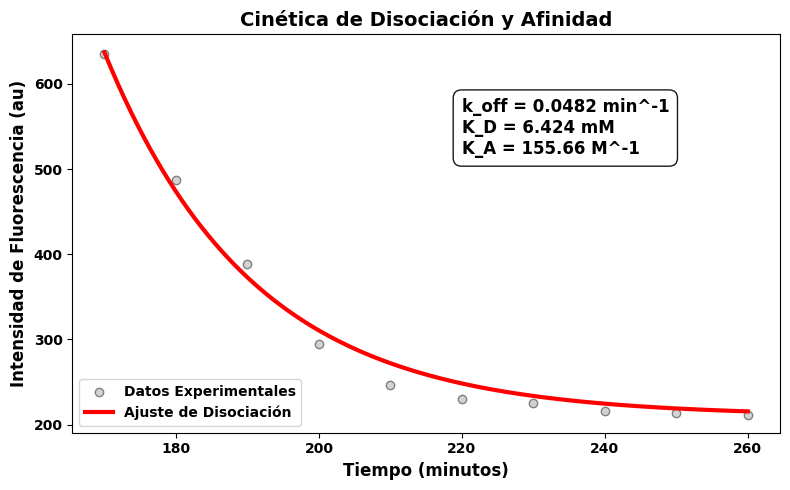

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Configurar todo el texto en negrita globalmente
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold', 'axes.titleweight': 'bold'})

# 2. Cargar los datos
df = pd.read_excel('DatosEnCrudo.xlsx', header=None)
tiempo_real = df[7].dropna().values
fluorescencia = df[8].dropna().values

# 3. Parámetros de Disociación y Afinidad
k_off = 0.04818
Y_max = 637.0
Fondo = 210.0
t_lavado = 170
Kd_mM = 6.424
Ka = 155.66

# 4. Filtrar datos (solo mostrar la fase de disociación)
mascara = (tiempo_real >= t_lavado)
t_datos = tiempo_real[mascara]
f_datos = fluorescencia[mascara]

# 5. Curva matemática teórica
t_teorico = np.linspace(t_lavado, max(tiempo_real), 100)
t_ajustado = t_teorico - t_lavado
curva_disoc = (Y_max - Fondo) * np.exp(-k_off * t_ajustado) + Fondo

# 6. Crear la gráfica
fig, ax = plt.subplots(figsize=(8, 5))

# Puntos y línea
ax.scatter(t_datos, f_datos, color='lightgray', edgecolors='gray', label='Datos Experimentales', zorder=1)
ax.plot(t_teorico, curva_disoc, color='red', linewidth=3, label='Ajuste de Disociación')

# Cuadro de texto con resultados (en negrita)
texto_resultados = (
    f"k_off = {k_off:.4f} min^-1\n"
    f"K_D = {Kd_mM:.3f} mM\n"
    f"K_A = {Ka:.2f} M^-1"
)
# Ubicación del cuadro a la derecha para no tapar la curva que cae
ax.text(0.55, 0.70, texto_resultados, transform=ax.transAxes, fontsize=12, fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.5'))

# Textos y títulos
ax.set_title('Cinética de Disociación y Afinidad', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (minutos)', fontsize=12, fontweight='bold')
ax.set_ylabel('Intensidad de Fluorescencia (au)', fontsize=12, fontweight='bold')

# Leyenda en negrita
legend = ax.legend(loc='lower left') # Movida a la izquierda para mejor estética
plt.setp(legend.get_texts(), weight='bold')

# Sin cuadrícula
ax.grid(False)

# Asegurar que los números de los ejes también estén en negrita
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontweight('bold')

plt.tight_layout()
plt.show()